In [1]:
import tensorflow as tf 

In [4]:
t = tf.constant([[1., 2., 3.], [4., 5., 6.]])
t

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[1., 2., 3.],
       [4., 5., 6.]], dtype=float32)>

In [9]:
t.shape, t.dtype 

(TensorShape([2, 3]), tf.float32)

In [18]:
import numpy as np

a = np.array([1, 2, 3])
t = tf.constant(a)
t

<tf.Tensor: shape=(3,), dtype=int64, numpy=array([1, 2, 3])>

In [20]:
t.numpy().dtype 

dtype('int64')

In [21]:
tf.square(a)

<tf.Tensor: shape=(3,), dtype=int64, numpy=array([1, 4, 9])>

In [23]:
np.square(t).dtype 

dtype('int64')

In [24]:
tf.Variable([[1, 2, 3], [4, 5, 6]])

<tf.Variable 'Variable:0' shape=(2, 3) dtype=int32, numpy=
array([[1, 2, 3],
       [4, 5, 6]], dtype=int32)>

In [25]:
tf.range(10)

<tf.Tensor: shape=(10,), dtype=int32, numpy=array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int32)>

In [27]:
tf.constant(np.arange(10))

<tf.Tensor: shape=(10,), dtype=int64, numpy=array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])>

In [30]:
import tensorflow as tf 
from tensorflow.keras.initializers import Ones

In [271]:
class MyLayerNorm(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, batch_input_shape):
        self.alpha = self.add_weight(name = "scale", shape = batch_input_shape[-1:], dtype = "float32", trainable = True, initializer = Ones())
        self.beta = self.add_weight(name = "shift", shape = batch_input_shape[-1:], dtype = "float32", trainable = True, initializer = 'zeros')
        super().build(batch_input_shape) # must be at the end

    def call(self, X):
        mean, variance = tf.nn.moments(X, axes = -1, keepdims=True)
        std = tf.sqrt(variance)
        epsilon = 0.001 
        output = self.alpha * (X - mean) / (epsilon + std) + self.beta 
        return output 

    def compute_output_shape(self, batch_input_shape):
        return batch_input_shape

In [272]:
my_layer_norm = MyLayerNorm()

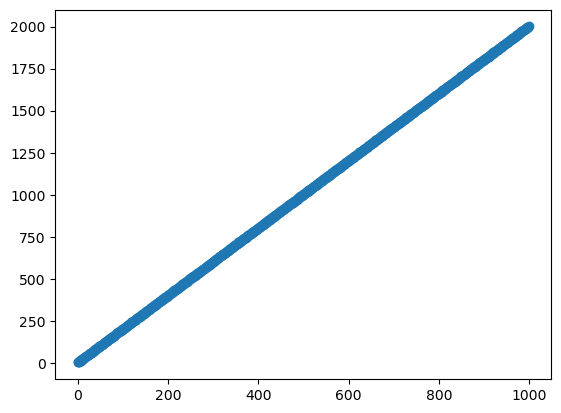

In [292]:
import numpy as np 
import matplotlib.pyplot as plt 
X = np.arange(1000)
y = 3 + 2 * X + np.random.randn(1000)
plt.scatter(X, y)

In [293]:
X.shape 

(1000,)

In [294]:
mean, std = np.mean(X), np.std(X)
X = (X - mean) / std 

In [295]:
X_train, y_train, X_val, y_val, X_test, y_test = X[:800], y[:800], X[800:900], y[800:900], X[900:], y[900:]

X_train = X_train.reshape(-1, 1)
X_val = X_val.reshape(-1, 1) 
X_test = X_test.reshape(-1, 1)

In [296]:
X_train.shape 

(800, 1)

In [297]:
model = tf.keras.Sequential([
    tf.keras.Input(shape = (1,)),
    tf.keras.layers.Dense(10),
    my_layer_norm, 
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1),

])

In [298]:
model.summary()

Model: "sequential_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_81 (Dense)                │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_layer_norm_5 (MyLayerNorm)   │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_82 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_83 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161 (644.00 B)

 Trainable params: 161 (644.00 B)

 Non-trainable params: 0 (0.00 B)

In [299]:
model.compile(optimizer='adam', loss='mse')

In [300]:
history = model.fit(X_train, y_train, epochs = 200, validation_data=(X_val, y_val))

Epoch 1/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 834549.0000 - val_loss: 2902555.0000
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 824839.0625 - val_loss: 2847374.0000
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 768453.6875 - val_loss: 2791010.2500
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 773089.1875 - val_loss: 2727315.0000
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 768099.0625 - val_loss: 2654075.5000
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 728927.5625 - val_loss: 2569022.7500
Epoch 7/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 691823.5625 - val_loss: 2465681.2500
Epoch 8/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 618726.1250 - val_loss: 2345593.0000
Epoch 9/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 530281.8750 - val_loss: 2203773.5000
Epoch 10/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 496944.3125 - val_loss: 2040697.0000
Epoch 11/200
25/25 ━━━━━━━━━━━━━━━━━━━━

# Train the fashion MNIST using a custom training loop in tensorflow 

In [364]:
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

In [369]:
l2_reg = tf.keras.regularizers.l2(0.05)
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape = [28, 28]),
    tf.keras.layers.Dense(30, activation="relu", kernel_initializer="he_normal", kernel_regularizer=l2_reg),
    tf.keras.layers.Dense(30, activation="relu", kernel_initializer="he_normal", kernel_regularizer=l2_reg),
    tf.keras.layers.Dense(30, activation="relu", kernel_initializer="he_normal", kernel_regularizer=l2_reg),
    tf.keras.layers.Dense(10, activation = 'softmax')
])
def random_batch(X, y, batch_size=32):
    idx = np.random.randint(len(X), size=batch_size)
    return X[idx], y[idx]

/Users/hendy/anaconda3/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [363]:
def print_status_bar(iteration, total, loss, metrics=None):
    metrics = " - ".join(["{}: {:.4f}".format(m.name, m.result())
                         for m in [loss] + (metrics or [])])
    end = "" if iteration < total else "\n"
    print("\r{}/{} - ".format(iteration, total) + metrics,
          end=end)

In [365]:
X_train_scaled = X_train / 255. 
X_valid_scaled = X_valid / 255. 

In [370]:
n_epochs = 5
batch_size = 32
n_steps = len(X_train) // batch_size
optimizer = tf.keras.optimizers.Nadam(learning_rate=0.01)
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()
mean_loss = tf.keras.metrics.Mean()
metrics = [tf.keras.metrics.Accuracy()]
validation_loss = tf.keras.metrics.Mean()
validation_accuracy = [tf.keras.metrics.Accuracy()]

for epoch in range(1, n_epochs + 1):
    print("Epoch {}/{}".format(epoch, n_epochs))
    for step in range(1, n_steps + 1):
        X_batch, y_batch = random_batch(X_train_scaled, y_train)
        with tf.GradientTape() as tape:
            y_pred = model(X_batch, training=True)
            main_loss = tf.reduce_mean(loss_fn(y_batch, y_pred))
            loss = tf.add_n([main_loss] + model.losses)
        gradients = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))
        mean_loss(loss)
        for metric in metrics:
            metric(y_batch, tf.math.argmax(y_pred, axis = -1))
        print_status_bar(step * batch_size, len(y_train), mean_loss, metrics)
    print_status_bar(len(y_train), len(y_train), mean_loss, metrics)
    for metric in [mean_loss] + metrics:
        metric.reset_state()
    # compute and print the validation loss and accuracy 
    for step in range(0, len(X_valid_scaled), batch_size):
        X_batch, y_batch = X_valid_scaled[step: step+batch_size], y_valid[step: step + batch_size]
        y_pred = model(X_batch, training=False)
        main_loss = tf.reduce_mean(loss_fn(y_batch, y_pred))
        loss = tf.add_n([main_loss] + model.losses)
        validation_loss(loss)
        validation_accuracy[0].update_state(y_batch, tf.math.argmax(y_pred, axis=-1))
    print("validation loss:", validation_loss.result().numpy(), "validation accuracy:", validation_accuracy[0].result().numpy())
    for metric in [validation_loss] + validation_accuracy:
        metric.reset_state()


Epoch 1/5
55000/55000 - mean: 1.2833 - accuracy: 0.6908
validation loss: 1.0270916 validation accuracy: 0.735
Epoch 2/5
55000/55000 - mean: 1.0379 - accuracy: 0.7187
validation loss: 1.2188644 validation accuracy: 0.6412
Epoch 3/5
55000/55000 - mean: 1.0271 - accuracy: 0.7209
validation loss: 0.9399377 validation accuracy: 0.7478
Epoch 4/5
55000/55000 - mean: 0.9962 - accuracy: 0.7273
validation loss: 0.9273054 validation accuracy: 0.765
Epoch 5/5
55000/55000 - mean: 0.9776 - accuracy: 0.7281
validation loss: 0.92785287 validation accuracy: 0.7484
